In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv("Titanic Dataset.csv")

print(df.head())
print(df.info())

In [ ]:
encoder = {}

for col in df.columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoder[col] = le

df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,0,1,21,0,44,0,0,187,273,43,2,11,121,308
1,0,1,23,1,6,1,2,49,270,79,2,2,121,230
2,0,0,24,0,8,1,2,49,270,79,2,27,121,230
3,0,0,25,1,45,1,2,49,270,79,2,27,53,230
4,0,0,26,0,38,1,2,49,270,79,2,27,121,230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,2,0,1291,0,22,1,0,259,111,186,0,27,120,369
1305,2,0,1292,0,98,1,0,259,111,186,0,27,121,369
1306,2,0,1293,1,40,0,0,250,18,186,0,27,111,369
1307,2,0,1294,1,41,0,0,264,18,186,0,27,121,369


In [ ]:
df = df.drop(['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest'], axis=1)

In [ ]:
X = df.drop("survived", axis=1)
y = df["survived"]

print('Features')
print(X)

Features
      pclass  sex  age  sibsp  parch  fare  embarked
0          0    0   44      0      0   273         2
1          0    1    6      1      2   270         2
2          0    0    8      1      2   270         2
3          0    1   45      1      2   270         2
4          0    0   38      1      2   270         2
...      ...  ...  ...    ...    ...   ...       ...
1304       2    0   22      1      0   111         0
1305       2    0   98      1      0   111         0
1306       2    1   40      0      0    18         0
1307       2    1   41      0      0    18         0
1308       2    1   44      0      0    46         2

[1309 rows x 7 columns]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1047, 7)
Testing Data Shape: (262, 7)


In [ ]:
# Create Model
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,   # Limits the tree depth
    random_state=42
)

# Train Model
model.fit(X, y)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
importance = model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, ":", score)

pclass : 0.2480196868837396
sex : 0.5837730250812804
age : 0.05367720893578474
sibsp : 0.05032428780602648
parch : 0.0
fare : 0.06420579129316879
embarked : 0.0


In [ ]:
new_data = pd.DataFrame({
    'pclass': [1],
    'sex': ['male'],
    'age': [30],
    'sibsp': [0],
    'parch': [0],
    'fare': [100],
    'embarked': ['S']
})

In [ ]:
new_data['sex'] = encoder['sex'].transform(new_data['sex'])
new_data['embarked'] = encoder['embarked'].transform(new_data['embarked'])

In [ ]:
prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Prediction: Survived")
else:
    print("Prediction: Not Survived")

Prediction: Not Survived


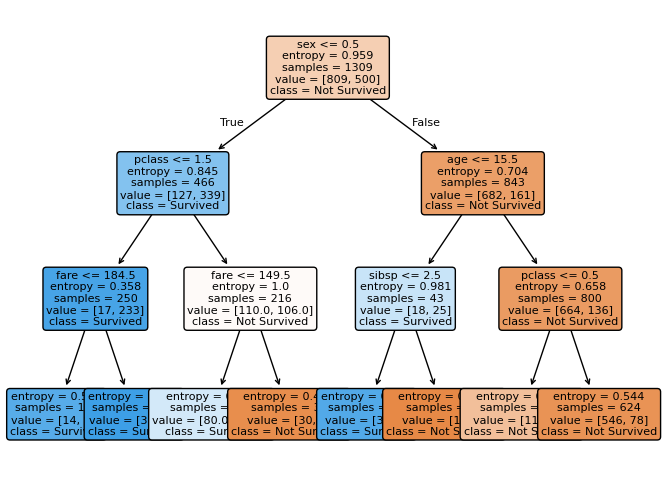

In [ ]:
plt.figure(figsize=(8,6))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

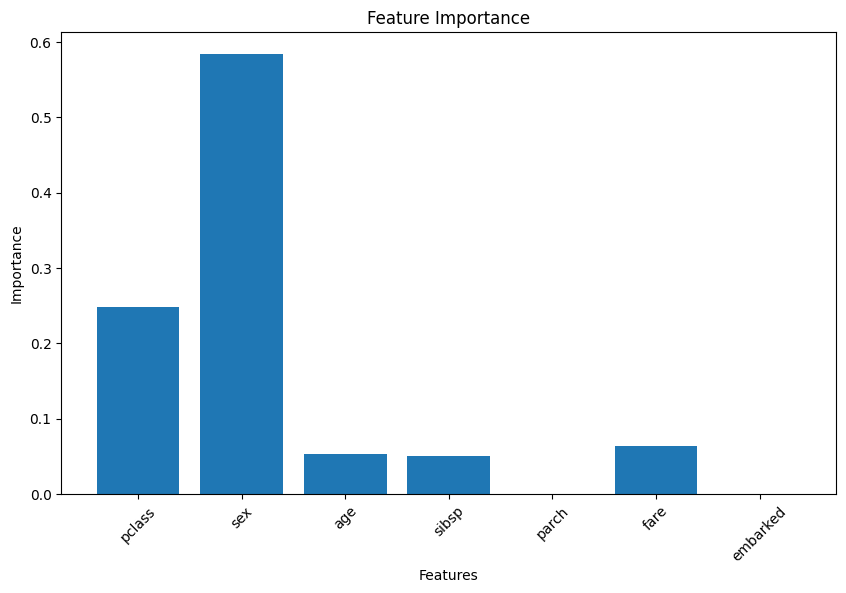

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    X.columns,
    model.feature_importances_
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X)

accuracy = accuracy_score(y, y_pred)

print("Accuracy =", accuracy * 100, "%")

Accuracy = 81.66539343009931 %
